# Mounting Google drive  

In [2]:
# Local development setup — VS Code + .venv
import os
import sys
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

if os.path.exists('/content/drive'):
    %ls
else:
    print("Drive not connected ! ")


Mounted at /content/drive
drive/  sample_data/


# Downlaoding the dataset 
* Move the dataset to /content folder - easier to preload

In [3]:
COLAB_DIR = Path("/content")
DATA_DIR = COLAB_DIR / "datasets"
DATA_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(DATA_DIR)


# 1. Download official archives
!wget -N https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip
!wget -N https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip
!wget -N https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip

# 2. Extract files into place
!unzip -q GTSRB_Final_Training_Images.zip
!unzip -q GTSRB_Final_Test_Images.zip
!unzip -q GTSRB_Final_Test_GT.zip


# 3. Clean up root directory structure
!mv GTSRB/* .
!rm -rf GTSRB GTSRB_Final_Training_Images.zip GTSRB_Final_Test_Images.zip GTSRB_Final_Test_GT.zip

TRAIN_DIR   = DATA_DIR / 'Final_Training' / 'Images'
TEST_DIR    = DATA_DIR / 'Final_Test' / 'Images'
TEST_CSV    = DATA_DIR / 'GT-final_test.csv'

IMG_SIZE    = 64
NUM_CLASSES = 43
VAL_SPLIT   = 0.2
RANDOM_SEED = 42
BATCH_SIZE  = 32

assert TRAIN_DIR.exists(), f"Training directory not found: {TRAIN_DIR}"
assert TEST_DIR.exists(),  f"Test directory not found: {TEST_DIR}"

print(f"Training directory : {TRAIN_DIR}")
print(f"Test directory     : {TEST_DIR}")

--2026-09-23 15:27:27--  https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip
Resolving sid.erda.dk (sid.erda.dk)... 130.225.104.13
Connecting to sid.erda.dk (sid.erda.dk)|130.225.104.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 276294756 (263M) [application/zip]
Saving to: ‘GTSRB_Final_Training_Images.zip’

GTSRB_Final_Trainin 100%[===================>] 263.50M  15.2MB/s    in 20s     

2026-09-23 15:27:48 (12.9 MB/s) - ‘GTSRB_Final_Training_Images.zip’ saved [276294756/276294756]

--2026-09-23 15:27:49--  https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip
Resolving sid.erda.dk (sid.erda.dk)... 130.225.104.13
Connecting to sid.erda.dk (sid.erda.dk)|130.225.104.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 88978620 (85M) [application/zip]
Saving to: ‘GTSRB_Final_Test_Images.zip’

GTSRB_Final_Test_Im 100%[===================>]  84.8

# Imports

In [4]:
import sys
import os
import glob
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches


import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight

import wandb

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0
GPU available: True


# Parsing the csv files

In [5]:
def parse_training_csvs(train_dir):
    """
    Walk through all 43 class folders.
    Read each GT-XXXXX.csv and extract:
        filepath | x1 | y1 | x2 | y2 | label
    Returns a single combined DataFrame.
    """
    all_records = []
    csv_files = sorted(glob.glob(str(train_dir / '*' / '*.csv')))

    for csv_path in csv_files:
        class_folder = Path(csv_path).parent
        df = pd.read_csv(csv_path, sep=';')

        for _, row in df.iterrows():
            img_path = class_folder / row['Filename']
            all_records.append({
                'filepath' : str(img_path),
                'x1'       : int(row['Roi.X1']),
                'y1'       : int(row['Roi.Y1']),
                'x2'       : int(row['Roi.X2']),
                'y2'       : int(row['Roi.Y2']),
                'label'    : int(row['ClassId'])
            })

    return pd.DataFrame(all_records)


df_train_full = parse_training_csvs(TRAIN_DIR)

print(f"Total training images : {len(df_train_full)}")
print(f"Unique classes        : {df_train_full['label'].nunique()}")
df_train_full.head()

Total training images : 39209
Unique classes        : 43


,filepath,x1,y1,x2,y2,label
0,/content/datasets/Final_Training/Images/00000/...,5,6,24,25,0
1,/content/datasets/Final_Training/Images/00000/...,5,5,25,25,0
2,/content/datasets/Final_Training/Images/00000/...,5,5,25,25,0
3,/content/datasets/Final_Training/Images/00000/...,5,5,26,26,0
4,/content/datasets/Final_Training/Images/00000/...,5,6,25,26,0


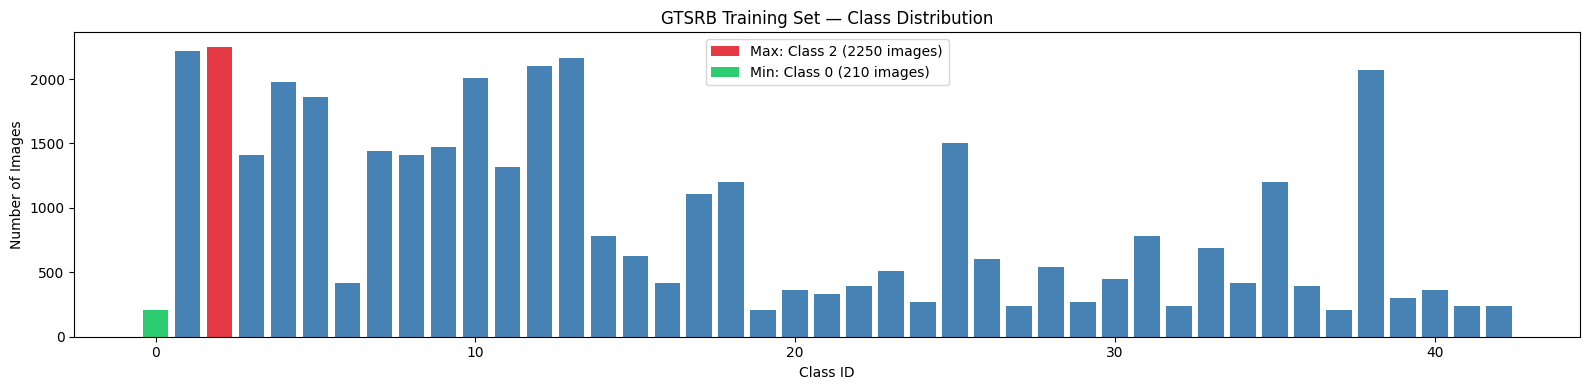

Imbalance ratio: 10.7x


In [6]:
class_counts = df_train_full['label'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(class_counts.index, class_counts.values, color='steelblue')

max_class = class_counts.idxmax()
min_class = class_counts.idxmin()
ax.bar(max_class, class_counts[max_class], color='#E63946',
       label=f'Max: Class {max_class} ({class_counts[max_class]} images)')
ax.bar(min_class, class_counts[min_class], color='#2ECC71',
       label=f'Min: Class {min_class} ({class_counts[min_class]} images)')

ax.set_xlabel('Class ID')
ax.set_ylabel('Number of Images')
ax.set_title('GTSRB Training Set — Class Distribution')
ax.legend()
plt.tight_layout()
plt.show()

ratio = class_counts.max() / class_counts.min()
print(f"Imbalance ratio: {ratio:.1f}x")

# Track-Aware Train/Val Split

GTSRB isn't independent photos — each physical sign was filmed as a short video,
so consecutive filenames (e.g. `00006_00021.ppm` ... `00006_00029.ppm`) are ~30
near-duplicate frames of the *same* sign. A plain `train_test_split` on individual
images has no notion of this and can put frame 24 of a track in train and frame 25
of the same track in val — that's not validation, it's near-memorization, and it's
why an earlier version of this split produced a suspicious 99.9% baseline accuracy.

Fix: split by *track*, not by image, so a whole track goes to one side only.
`track_key` = class folder + track number, since track numbers reset per class.

We tried plain `GroupShuffleSplit` first — it respects track boundaries but,
with 43 competing classes and some classes as small as 1-2 tracks, a single
random group split can accidentally leave a whole class out of val entirely
(this happened to classes 0, 19, 34 in our first attempt). `StratifiedGroupKFold`
searches across multiple fold arrangements instead, and we pick whichever fold
covers all 43 classes in val.

In [7]:
def make_track_key(filepath):
    """
    class folder + track number, e.g. ".../00000/00000_00029.ppm" -> "00000_00000"
    Track numbers reset per class folder, so folder+track together is the
    actual unique key — track "00000" in class 0 and class 5 are different tracks.
    """
    p = Path(filepath)
    track_num = p.stem.split("_")[0]
    return f"{p.parent.name}_{track_num}"

df_train_full["track_key"] = df_train_full["filepath"].apply(make_track_key)
print(f"Unique tracks: {df_train_full['track_key'].nunique()}")

Unique tracks: 1307


In [8]:
n_splits = int(round(1 / VAL_SPLIT))  # VAL_SPLIT=0.2 -> 5 folds, take 1 as val
sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)

best_fold, best_missing = None, NUM_CLASSES + 1
best_train_idx, best_val_idx = None, None

for fold_idx, (tr_idx, va_idx) in enumerate(
    sgkf.split(df_train_full, y=df_train_full["label"], groups=df_train_full["track_key"])
):
    missing = set(range(NUM_CLASSES)) - set(df_train_full.iloc[va_idx]["label"])
    print(f"Fold {fold_idx}: {len(missing)} missing classes -> {sorted(missing)}")
    if len(missing) < best_missing:
        best_missing = len(missing)
        best_fold = fold_idx
        best_train_idx, best_val_idx = tr_idx, va_idx

print(f"\nUsing fold {best_fold}, missing {best_missing} class(es) from val")

df_train_split = df_train_full.iloc[best_train_idx].reset_index(drop=True)
df_val_split   = df_train_full.iloc[best_val_idx].reset_index(drop=True)

Fold 0: 1 missing classes -> [24]
Fold 1: 0 missing classes -> []
Fold 2: 1 missing classes -> [37]
Fold 3: 1 missing classes -> [39]
Fold 4: 1 missing classes -> [27]

Using fold 1, missing 0 class(es) from val


In [9]:
# Verify: no track leakage, full class coverage on both sides
train_keys = set(df_train_split["track_key"])
val_keys   = set(df_val_split["track_key"])
assert len(train_keys & val_keys) == 0, "Leakage present!"

missing_train = set(range(NUM_CLASSES)) - set(df_train_split["label"])
missing_val   = set(range(NUM_CLASSES)) - set(df_val_split["label"])
print(f"Train size: {len(df_train_split)}, Val size: {len(df_val_split)}")
print(f"Missing from train: {sorted(missing_train)}")
print(f"Missing from val:   {sorted(missing_val)}")
print("No track overlap — split is clean.")

Train size: 31349, Val size: 7860
Missing from train: []
Missing from val:   []
No track overlap — split is clean.


In [10]:
def load_and_resize_only(filepath, img_size=IMG_SIZE):
    """
    Load image and resize WITHOUT bounding box crop.
    Used for baseline runs 1, 2, 3.

    Why: we need to measure the effect of bounding box cropping
    separately in Run 4. If all arrays are pre-cropped, Run 4
    has nothing to contribute to the ablation story.
    """
    img = cv2.imread(filepath)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size),
                     interpolation=cv2.INTER_AREA)
    return img.astype(np.float32) / 255.0


def load_dataset_uncropped(df, img_size=IMG_SIZE):
    X = np.zeros((len(df), img_size, img_size, 3), dtype=np.float32)
    y = np.zeros(len(df), dtype=np.int32)

    for i, (_, row) in enumerate(df.iterrows()):
        X[i] = load_and_resize_only(row['filepath'], img_size)
        y[i] = row['label']

        if (i + 1) % 5000 == 0:
            print(f"  Loaded {i+1}/{len(df)} images...")

    return X, y

print("Uncropped loader ready.")

Uncropped loader ready.


Loading uncropped train/val — takes a few minutes...
  Loaded 5000/31349 images...
  Loaded 10000/31349 images...
  Loaded 15000/31349 images...
  Loaded 20000/31349 images...
  Loaded 25000/31349 images...
  Loaded 30000/31349 images...
  Loaded 5000/7860 images...
X_train_unc : (31349, 64, 64, 3)
X_val_unc   : (7860, 64, 64, 3)


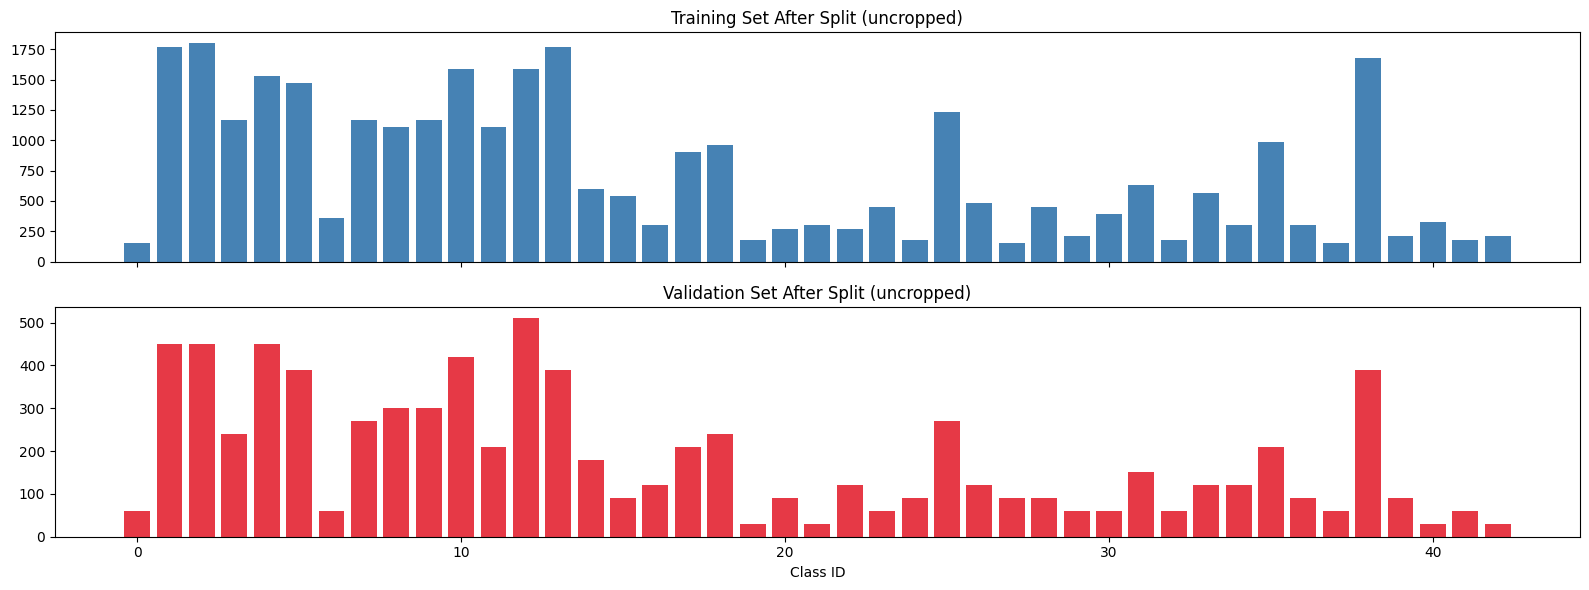

Train imbalance ratio : 12.0×
Val imbalance ratio   : 17.0×


In [11]:
print("Loading uncropped train/val — takes a few minutes...")
X_train_unc, y_train_unc = load_dataset_uncropped(df_train_split)
X_val_unc, y_val_unc     = load_dataset_uncropped(df_val_split)

print(f"X_train_unc : {X_train_unc.shape}")
print(f"X_val_unc   : {X_val_unc.shape}")

# Verify — proportions should look similar, though not identical
# (StratifiedGroupKFold balances as well as group constraints allow, not perfectly)
train_unc_counts = pd.Series(y_train_unc).value_counts().sort_index()
val_unc_counts   = pd.Series(y_val_unc).value_counts().sort_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
axes[0].bar(train_unc_counts.index, train_unc_counts.values, color='steelblue')
axes[0].set_title('Training Set After Split (uncropped)')
axes[1].bar(val_unc_counts.index, val_unc_counts.values, color='#E63946')
axes[1].set_title('Validation Set After Split (uncropped)')
axes[1].set_xlabel('Class ID')
plt.tight_layout()
plt.show()

print(f"Train imbalance ratio : {train_unc_counts.max()/train_unc_counts.min():.1f}×")
print(f"Val imbalance ratio   : {val_unc_counts.max()/val_unc_counts.min():.1f}×")

In [12]:
def load_and_crop(filepath, x1, y1, x2, y2, img_size=IMG_SIZE, padding=0.05):
    """
    Load image → crop to bounding box (+ 5% padding) → resize → normalise.

    Why padding: tight crop sometimes clips the sign border.
    Why INTER_AREA: best interpolation for downscaling — preserves fine details.
    Why /255.0: normalise to [0,1] for stable gradient flow during training.
    """
    img = cv2.imread(filepath)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    pad_x = int((x2 - x1) * padding)
    pad_y = int((y2 - y1) * padding)
    x1_p = max(0, x1 - pad_x)
    y1_p = max(0, y1 - pad_y)
    x2_p = min(w, x2 + pad_x)
    y2_p = min(h, y2 + pad_y)

    cropped = img[y1_p:y2_p, x1_p:x2_p]
    resized = cv2.resize(cropped, (img_size, img_size), interpolation=cv2.INTER_AREA)
    normalised = resized.astype(np.float32) / 255.0

    return normalised

def load_dataset_cropped(df, img_size=IMG_SIZE):
    X = np.zeros((len(df), img_size, img_size, 3), dtype=np.float32)
    y = np.zeros(len(df), dtype=np.int32)

    for i, (_, row) in enumerate(df.iterrows()):
        X[i] = load_and_crop(row['filepath'],
                             row['x1'], row['y1'],
                             row['x2'], row['y2'],
                             img_size=img_size)
        y[i] = row['label']

        if (i + 1) % 5000 == 0:
            print(f"  Loaded {i+1}/{len(df)} images...")

    return X, y

print("Cropped loader ready.")

Cropped loader ready.


In [13]:
print("Loading cropped train/val — takes a few minutes...")
X_train_crp, y_train_crp = load_dataset_cropped(df_train_split)
X_val_crp, y_val_crp     = load_dataset_cropped(df_val_split)

print(f"X_train_crp : {X_train_crp.shape}")
print(f"X_val_crp   : {X_val_crp.shape}")
print(f"Pixel range : [{X_train_crp.min():.3f}, {X_train_crp.max():.3f}]")

# Must be identical to y_train_unc/y_val_unc — same split, both branches
# loop over df_train_split/df_val_split in the same row order.
print("Labels match uncropped split:",
      np.array_equal(y_train_crp, y_train_unc) and np.array_equal(y_val_crp, y_val_unc))

Loading cropped train/val — takes a few minutes...
  Loaded 5000/31349 images...
  Loaded 10000/31349 images...
  Loaded 15000/31349 images...
  Loaded 20000/31349 images...
  Loaded 25000/31349 images...
  Loaded 30000/31349 images...
  Loaded 5000/7860 images...
X_train_crp : (31349, 64, 64, 3)
X_val_crp   : (7860, 64, 64, 3)
Pixel range : [0.000, 1.000]
Labels match uncropped split: True


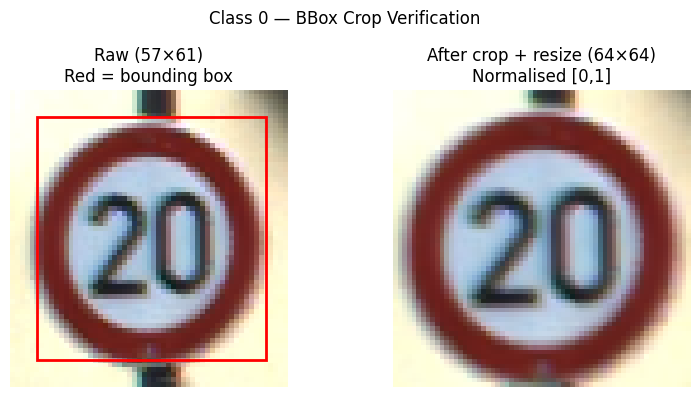

Raw shape     : (61, 57, 3)
Cropped shape : (64, 64, 3)
Pixel range   : [0.055, 1.000]


In [14]:
# ── Visual verification on one image ─────────────────────────────
sample = df_train_full.iloc[123]

raw_img = cv2.cvtColor(cv2.imread(sample['filepath']), cv2.COLOR_BGR2RGB)
cropped_img = load_and_crop(sample['filepath'],
                            sample['x1'], sample['y1'],
                            sample['x2'], sample['y2'])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(raw_img)
rect = patches.Rectangle(
    (sample['x1'], sample['y1']),
    sample['x2'] - sample['x1'],
    sample['y2'] - sample['y1'],
    linewidth=2, edgecolor='red', facecolor='none'
)
axes[0].add_patch(rect)
axes[0].set_title(f"Raw ({raw_img.shape[1]}×{raw_img.shape[0]})\nRed = bounding box")
axes[0].axis('off')

axes[1].imshow(cropped_img)
axes[1].set_title(f"After crop + resize ({IMG_SIZE}×{IMG_SIZE})\nNormalised [0,1]")
axes[1].axis('off')

plt.suptitle(f"Class {sample['label']} — BBox Crop Verification")
plt.tight_layout()
plt.show()

print(f"Raw shape     : {raw_img.shape}")
print(f"Cropped shape : {cropped_img.shape}")
print(f"Pixel range   : [{cropped_img.min():.3f}, {cropped_img.max():.3f}]")

Min weight : 0.405  (most common class)
Max weight : 4.860  (rarest class)
Ratio : 12.0×


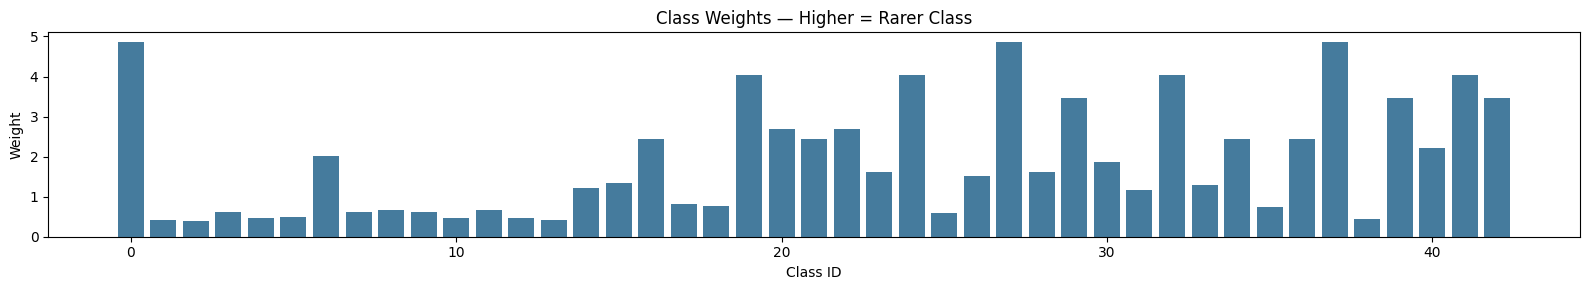

In [15]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_unc),
    y=y_train_unc
)
assert len(class_weights_array) == NUM_CLASSES, (
    f"Expected {NUM_CLASSES} classes in y_train_unc, got {len(class_weights_array)} — "
    "check whether the winning fold left a class out of train."
)
class_weight_dict = dict(enumerate(class_weights_array))

print(f"Min weight : {class_weights_array.min():.3f}  (most common class)")
print(f"Max weight : {class_weights_array.max():.3f}  (rarest class)")
print(f"Ratio : {class_weights_array.max()/class_weights_array.min():.1f}×")

fig, ax = plt.subplots(figsize=(16, 3))
ax.bar(range(NUM_CLASSES), class_weights_array, color='#457B9D')
ax.set_xlabel('Class ID')
ax.set_ylabel('Weight')
ax.set_title('Class Weights — Higher = Rarer Class')
plt.tight_layout()
plt.show()

# Visualise Augmentation

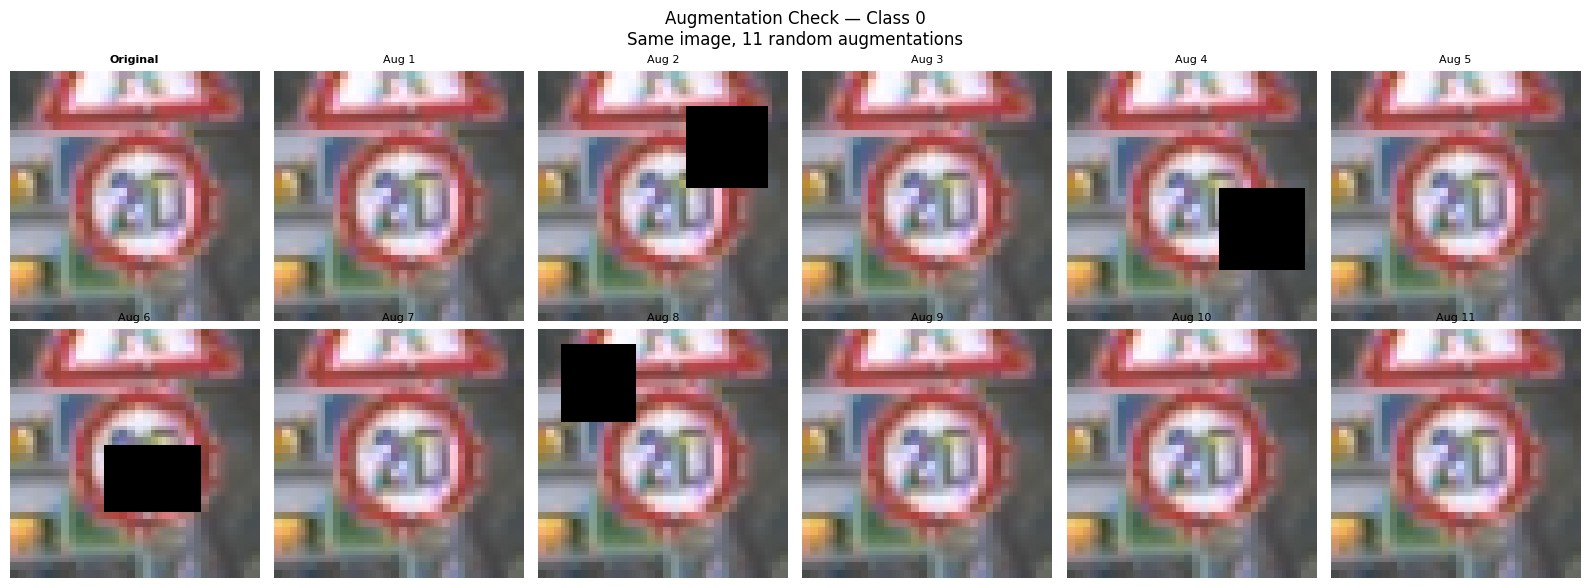

In [18]:
PROJECT_DIR = Path("/content/drive/MyDrive/Group_E/Final_Project/03-Code")
os.chdir(PROJECT_DIR)
from src.augmentation import RandomErasing

erasing_layer = RandomErasing(probability=0.5)

# 2. Extract a single image to augment, e.g., shape (1, H, W, C)
single_img =  X_train_unc[1:100]

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
axes = axes.flatten()

# Display Original
axes[0].imshow(np.clip(single_img[0], 0.0, 1.0))
axes[0].set_title("Original", fontweight="bold", fontsize=8)
axes[0].axis("off")

# Display 11 Augmentations
for i in range(1, 12):
  aug = erasing_layer(single_img, training=True)

  # aug is a TensorFlow tensor, convert/clip for plotting
  axes[i].imshow(np.clip(aug[0].numpy(), 0.0, 1.0))
  axes[i].set_title(f"Aug {i}", fontsize=8)
  axes[i].axis("off")

plt.suptitle(
    f"Augmentation Check — Class {y_train_unc[0]}\nSame image, 11 random"
    " augmentations"
)
plt.tight_layout()
plt.show()

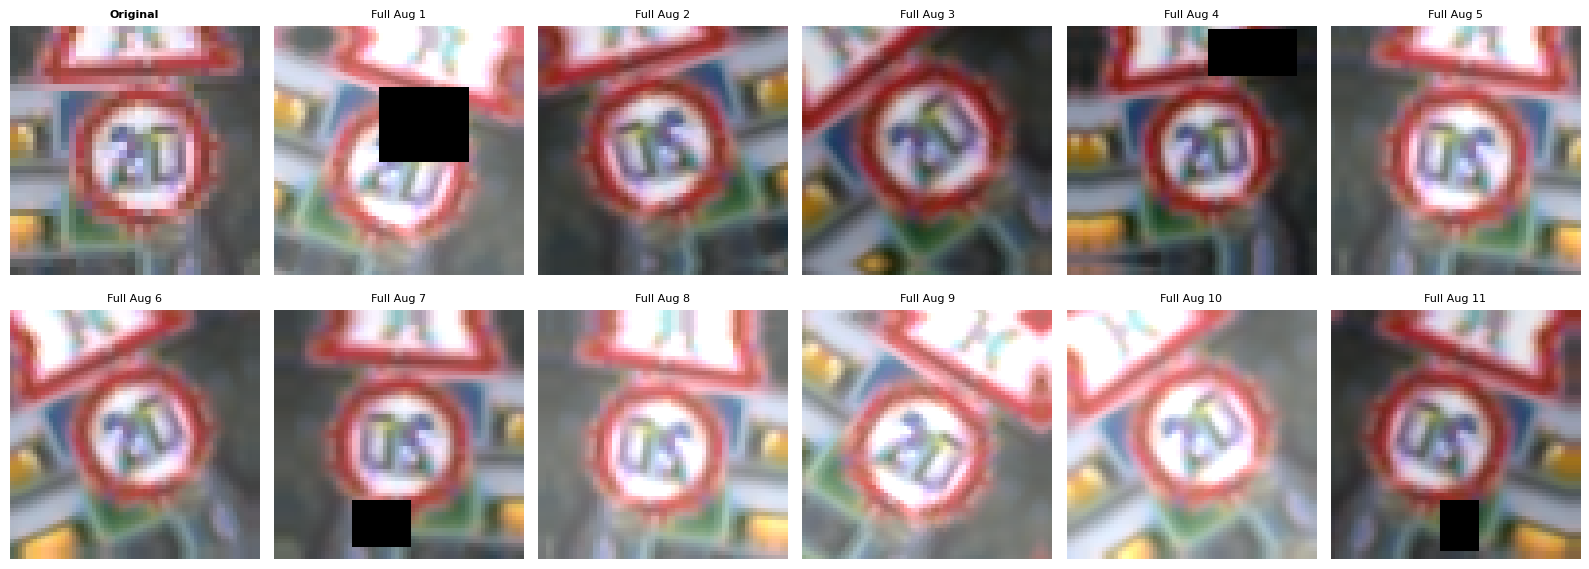

In [20]:
from src.augmentation import build_augmentation_pipeline

aug_pipeline = build_augmentation_pipeline()
single_img =  X_train_unc[1:100]

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
axes = axes.flatten()

axes[0].imshow(np.clip(single_img[0], 0.0, 1.0))
axes[0].set_title("Original", fontweight="bold", fontsize=8)
axes[0].axis("off")

for i in range(1, 12):
  aug = aug_pipeline(single_img, training=True)
  axes[i].imshow(np.clip(aug[0].numpy(), 0.0, 1.0))
  axes[i].set_title(f"Full Aug {i}", fontsize=8)
  axes[i].axis("off")

plt.tight_layout()
plt.show()

In [21]:
print(np.array_equal(y_train_crp, y_train_unc))  # should print True

True


# tf.data Pipeline

In [22]:
def build_dataset(X, y, batch_size=BATCH_SIZE, shuffle=False, cache=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if cache:
        ds = ds.cache()
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=RANDOM_SEED)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_unc_ds = build_dataset(X_train_unc, y_train_unc, shuffle=True,  cache=True)
val_unc_ds   = build_dataset(X_val_unc,   y_val_unc,   shuffle=False, cache=True)

print(f"Training batches   : {len(train_unc_ds)}")
print(f"Validation batches : {len(val_unc_ds)}")

for imgs, labels in train_unc_ds.take(1):
    print(f"Batch image shape  : {imgs.shape}")
    print(f"Batch label shape  : {labels.shape}")

Training batches   : 980
Validation batches : 246
Batch image shape  : (32, 64, 64, 3)
Batch label shape  : (32,)


In [23]:
def load_test_set(test_dir, test_csv_path, img_size=IMG_SIZE):
    df_test = pd.read_csv(test_csv_path, sep=';')
    X_test  = np.zeros((len(df_test), img_size, img_size, 3), dtype=np.float32)
    y_test  = np.zeros(len(df_test), dtype=np.int32)

    for i, (_, row) in enumerate(df_test.iterrows()):
        img  = cv2.imread(str(test_dir / row['Filename']))
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img  = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA)
        X_test[i] = img.astype(np.float32) / 255.0
        y_test[i] = int(row['ClassId'])

        if (i + 1) % 2000 == 0:
            print(f"  Loaded {i+1}/{len(df_test)} test images...")

    return X_test, y_test


X_test, y_test = load_test_set(TEST_DIR, TEST_CSV)
test_ds = build_dataset(X_test, y_test, shuffle=False, cache=True)

print(f"X_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")

  Loaded 2000/12630 test images...
  Loaded 4000/12630 test images...
  Loaded 6000/12630 test images...
  Loaded 8000/12630 test images...
  Loaded 10000/12630 test images...
  Loaded 12000/12630 test images...
X_test shape : (12630, 64, 64, 3)
y_test shape : (12630,)


In [24]:
PROCESSED_DIR  = DATA_DIR / "processed"
CROPPED_DIR    = PROCESSED_DIR / "cropped"
UNCROPPED_DIR  = PROCESSED_DIR / "uncropped"

CROPPED_DIR.mkdir(parents=True, exist_ok=True)
UNCROPPED_DIR.mkdir(parents=True, exist_ok=True)

# Cropped — Runs 4, 5
np.save(str(CROPPED_DIR / 'X_train.npy'), X_train_crp)
np.save(str(CROPPED_DIR / 'y_train.npy'), y_train_crp)
np.save(str(CROPPED_DIR / 'X_val.npy'), X_val_crp)
np.save(str(CROPPED_DIR / 'y_val.npy'), y_val_crp)

# Uncropped — Runs 1, 2, 3
np.save(str(UNCROPPED_DIR / 'X_train.npy'), X_train_unc)
np.save(str(UNCROPPED_DIR / 'y_train.npy'), y_train_unc)
np.save(str(UNCROPPED_DIR / 'X_val.npy'),   X_val_unc)
np.save(str(UNCROPPED_DIR / 'y_val.npy'),   y_val_unc)

# Shared — all runs
np.save(str(PROCESSED_DIR / 'X_test.npy'), X_test)
np.save(str(PROCESSED_DIR / 'y_test.npy'), y_test)
np.save(str(PROCESSED_DIR / 'class_weights.npy'), class_weights_array)

print("All arrays saved.")
print(f"Cropped   : {CROPPED_DIR}")
print(f"Uncropped : {UNCROPPED_DIR}")
print(f"Shared    : {PROCESSED_DIR}")

All arrays saved.
Cropped   : /content/datasets/processed/cropped
Uncropped : /content/datasets/processed/uncropped
Shared    : /content/datasets/processed


In [26]:
def load_test_set_cropped(test_dir, test_csv_path, img_size=IMG_SIZE):
    df_test = pd.read_csv(test_csv_path, sep=';')
    X = np.zeros((len(df_test), img_size, img_size, 3), dtype=np.float32)
    y = np.zeros(len(df_test), dtype=np.int32)

    for i, (_, row) in enumerate(df_test.iterrows()):
        filepath = str(test_dir / row['Filename'])
        X[i] = load_and_crop(
            filepath,
            int(row['Roi.X1']), int(row['Roi.Y1']),
            int(row['Roi.X2']), int(row['Roi.Y2']),
            img_size=img_size,
        )
        y[i] = int(row['ClassId'])

        if (i + 1) % 2000 == 0:
            print(f"  Loaded {i+1}/{len(df_test)} cropped test images...")

    return X, y


X_test_cropped, y_test_cropped = load_test_set_cropped(TEST_DIR, TEST_CSV)

# labels should be identical to the uncropped test set — same images, same order
assert np.array_equal(y_test_cropped, y_test), "Label mismatch between cropped/uncropped test sets!"

np.save(str(PROCESSED_DIR / 'X_test_cropped.npy'), X_test_cropped)
np.save(str(PROCESSED_DIR / 'y_test_cropped.npy'), y_test_cropped)
print("Saved cropped test set.")

  Loaded 2000/12630 cropped test images...
  Loaded 4000/12630 cropped test images...
  Loaded 6000/12630 cropped test images...
  Loaded 8000/12630 cropped test images...
  Loaded 10000/12630 cropped test images...
  Loaded 12000/12630 cropped test images...
Saved cropped test set.
